# MSCS 634 - Project Deliverable 1
# Data Collection, Cleaning, and Exploration

**Dataset:** Telco Customer Churn (IBM sample dataset)

**Author:** Samia Zaman

This notebook covers the first phase of the semester project: selecting a dataset, loading and
inspecting it, cleaning it, and exploring it visually. The insights from this notebook set up the
work for later deliverables (regression, classification, clustering, and association rule mining).

## 1. Dataset Selection and Justification

**Dataset:** [Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) (IBM sample
dataset, widely used for churn analysis coursework and available on Kaggle as well).

**Why this dataset fits the project:**

- **Size:** 7,043 rows and 21 columns (large enough)
- **Mix of variable types:** it has numeric fields (`tenure`, `MonthlyCharges`, `TotalCharges`),
  binary categorical fields (`Partner`, `Dependents`, `PaperlessBilling`, `Churn`), and multi-level
  categorical fields (`Contract`, `PaymentMethod`, `InternetService`, streaming/security add-ons).
  This mix is will build a rich project across the upcoming deliverable. 
  - **Regression (Deliverable 2):** predict a continuous target like `MonthlyCharges` or `TotalCharges`
    from customer/service attributes.
  - **Classification (Deliverable 3):** predict `Churn` (Yes/No) - a realistic, business-relevant
    binary classification problem.
  - **Clustering (Deliverable 3):** segment customers by usage and billing behavior.
  - **Association rule mining (Deliverable 3):** the many categorical service columns (internet
    service, streaming, security, backup, contract type) are well suited to finding frequent
    itemsets/rules, e.g., which service bundles tend to co-occur with churn.
- **Real-world relevance:** customer churn is a classic, practical business problem (subscription
  services, telecom, SaaS), so the modeling results and recommendations are easy to interpret and
  explain.
- **Realistic data quality issues:** the dataset has a small amount of genuinely messy data (see
  Section 3), which gives an authentic cleaning exercise rather than a synthetic one.

## 2. Load the Dataset and Inspect Its Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/Telco-Customer-Churn.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Structure: column names, dtypes, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Summary of categorical columns
df.describe(include="object")

/var/folders/z1/s419t3bj1ws4917vrtpdcflm0000gn/T/ipykernel_73639/292326849.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Data Cleaning

We check, in order: missing values, duplicates, and noisy/inconsistent data.

### 3.1 Missing Values

`df.info()` above shows no `NaN` values, but that's misleading: `TotalCharges` is loaded as a
**string** column instead of numeric, which usually means it contains non-numeric entries (blank
strings, stray whitespace, etc.) hiding as valid-looking non-null values. Let's check.

In [5]:
# TotalCharges should be numeric - coerce it and see which rows fail
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_mask = total_charges_numeric.isna()
print(f"Rows where TotalCharges is not numeric: {missing_mask.sum()}")
df.loc[missing_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows where TotalCharges is not numeric: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Finding:** 11 rows have a blank string for `TotalCharges`. Every one of these rows has
`tenure == 0`, i.e., these are brand-new customers who haven't been billed for a full cycle yet.
That's why the field is blank rather than genuinely random/missing-at-random data - it's a logical
consequence of `tenure`.

**Decision:** convert `TotalCharges` to numeric, then fill these 11 rows with `0` (a new customer
with 0 months of tenure has accrued 0 total charges), rather than dropping the rows or imputing
with the mean, since that would misrepresent brand-new customers as average ones.

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Remaining missing values in TotalCharges:", df["TotalCharges"].isna().sum())
print()
print("Missing values per column:")
print(df.isna().sum())

Remaining missing values in TotalCharges: 0

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 3.2 Duplicates

Check for fully duplicated rows and for duplicated `customerID` values (the primary key - a
duplicate ID would indicate a data entry error even if the rest of the row differs).

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID values:", df["customerID"].duplicated().sum())

Fully duplicated rows: 0
Duplicated customerID values: 0


**Finding:** no duplicate rows and no duplicate customer IDs, so no rows need to be dropped
for this dataset. This check is still worth doing explicitly since duplicate customer records are
one of the most common data quality problems in real subscription/billing data.

### 3.3 Noisy / Inconsistent Data

A few cleanup steps to make the data consistent and modeling-ready for later deliverables:

- `customerID` is a unique identifier, not a predictive feature - drop it before any later
  modeling steps to avoid leaking a pseudo-random key into a model. We keep a copy of the raw
  dataframe and drop it into a modeling-ready copy (`df_clean`) so both are available.
- `SeniorCitizen` is stored as `0`/`1` while every other binary field in the dataset (`Partner`,
  `Dependents`, `PhoneService`, ...) is stored as `"No"`/`"Yes"`. Recoding it to `"No"`/`"Yes"`
  makes it consistent with the rest of the categorical fields and easier to plot alongside them.
- Several service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
  `StreamingTV`, `StreamingMovies`) use `"No internet service"` as a third category, and
  `MultipleLines` uses `"No phone service"`. These aren't errors - they're structurally meaningful
  (the customer doesn't have the base service at all) - so we leave them as separate categories
  rather than collapsing them into `"No"`, which would lose information relevant to future
  classification and association-rule-mining steps.
- Sanity-check numeric ranges for `tenure` (should be >= 0 and reasonably bounded) and
  `MonthlyCharges`/`TotalCharges` (should be >= 0) to catch obviously invalid/noisy entries.

In [8]:
df_clean = df.drop(columns=["customerID"]).copy()

df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Sanity-check numeric ranges
print("tenure range:", df_clean["tenure"].min(), "-", df_clean["tenure"].max())
print("MonthlyCharges range:", df_clean["MonthlyCharges"].min(), "-", df_clean["MonthlyCharges"].max())
print("TotalCharges range:", df_clean["TotalCharges"].min(), "-", df_clean["TotalCharges"].max())
print()
print("Any negative values in numeric columns?")
print((df_clean[["tenure", "MonthlyCharges", "TotalCharges"]] < 0).sum())

tenure range: 0 - 72
MonthlyCharges range: 18.25 - 118.75
TotalCharges range: 0.0 - 8684.8

Any negative values in numeric columns?
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


**Finding:** all numeric ranges are sane (no negative charges or tenure, tenure tops out at
72 months which matches a 6-year-old dataset with monthly billing), so there's no noisy numeric
data to correct beyond what was already handled in Section 3.1.

In [9]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis (EDA)

We look at: the target class balance (`Churn`), distributions of the three numeric fields,
outliers, and relationships between key categorical fields and churn.

### 4.1 Churn Distribution (Target Class Balance)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


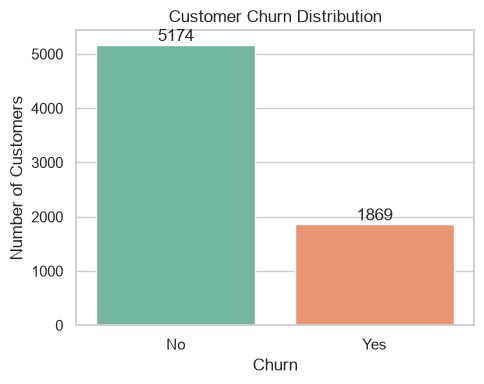

In [10]:
churn_counts = df_clean["Churn"].value_counts()
churn_pct = df_clean["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(1))

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df_clean, x="Churn", hue="Churn", palette="Set2", legend=False)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

**Insight:** about 26.5% of customers churned vs. 73.5% who stayed. This is a **moderate
class imbalance** - important to keep in mind for Deliverable 3's classification models (accuracy
alone won't be a reliable metric; we'll want precision/recall/F1 and possibly resampling or
class-weighting).

### 4.2 Distributions of Numeric Features

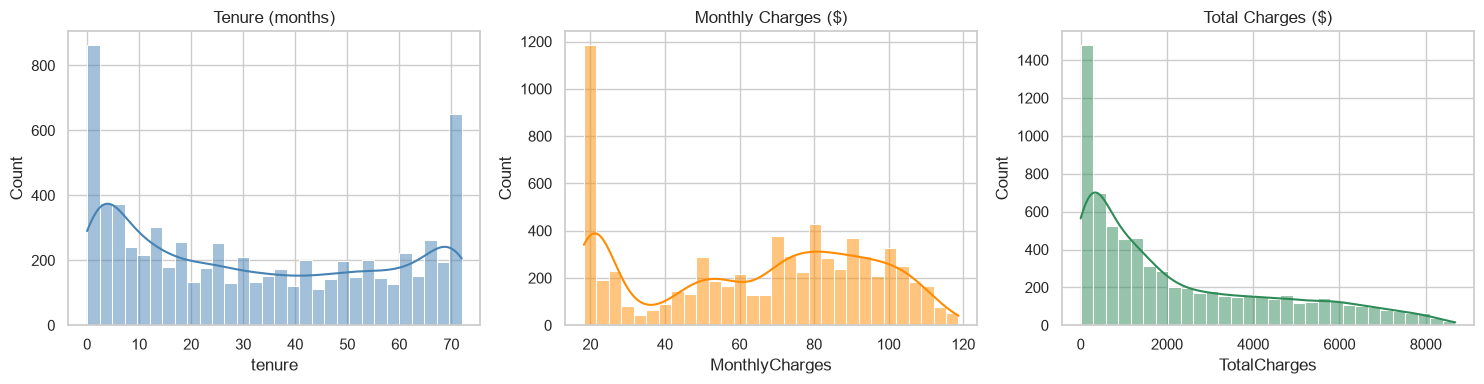

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_clean["tenure"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Tenure (months)")

sns.histplot(df_clean["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Monthly Charges ($)")

sns.histplot(df_clean["TotalCharges"], bins=30, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Total Charges ($)")

plt.tight_layout()
plt.show()

**Insight:** `tenure` is bimodal - a large spike of very new customers (near 0 months) and
another cluster near 70+ months (long-tenured, loyal customers), with fewer customers in between.
`MonthlyCharges` is spread fairly broadly with a cluster of low-cost customers (likely
phone-service-only) and a second bump at higher price points (likely fiber + add-ons).
`TotalCharges` is right-skewed, which makes sense since it's roughly `tenure x MonthlyCharges` -
it will need a log transform or similar if used as a regression target in Deliverable 2.

### 4.3 Outlier Check

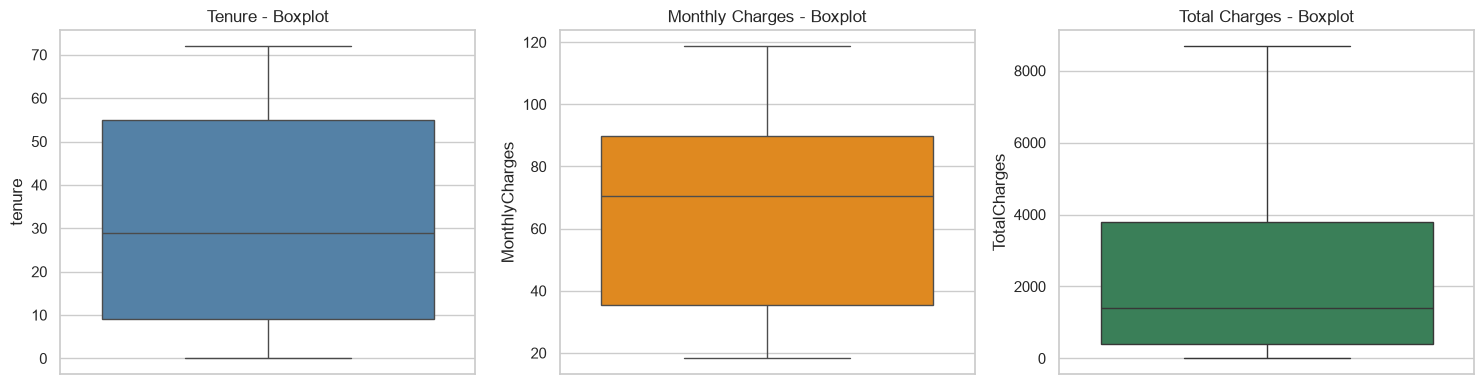

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df_clean["tenure"], ax=axes[0], color="steelblue")
axes[0].set_title("Tenure - Boxplot")

sns.boxplot(y=df_clean["MonthlyCharges"], ax=axes[1], color="darkorange")
axes[1].set_title("Monthly Charges - Boxplot")

sns.boxplot(y=df_clean["TotalCharges"], ax=axes[2], color="seagreen")
axes[2].set_title("Total Charges - Boxplot")

plt.tight_layout()
plt.show()

**Insight:** none of the three numeric fields show extreme outliers via the IQR whisker
rule - the boxplots are consistent with the skewed-but-plausible distributions seen above (e.g.
the high end of `TotalCharges` belongs to genuinely long-tenured, high-paying customers, not data
errors). No outlier removal was necessary.

### 4.4 Churn by Key Categorical Features

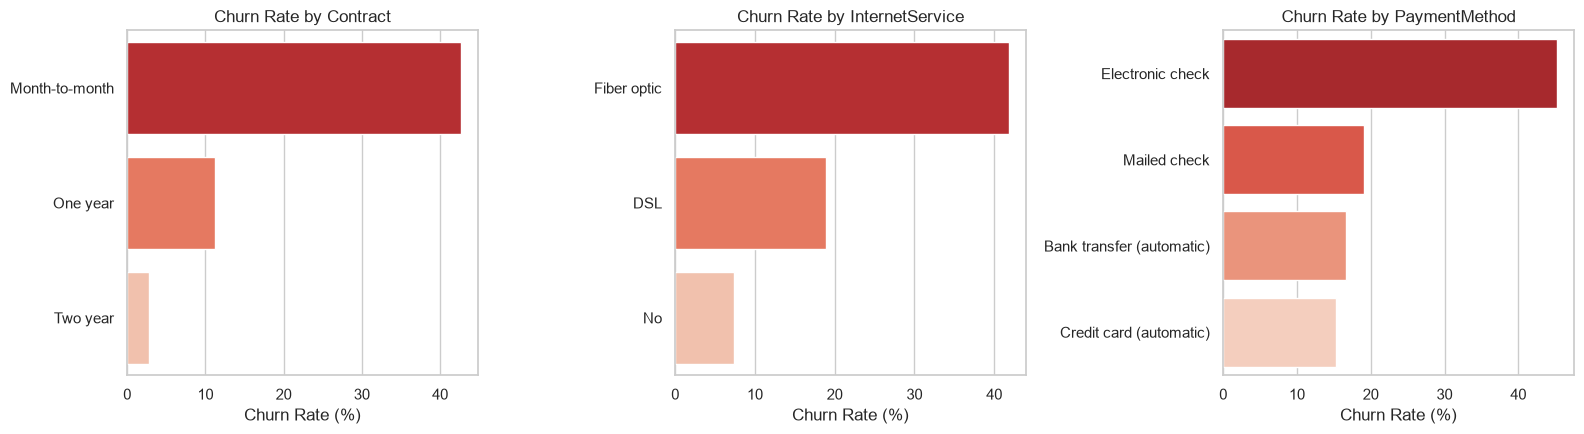

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    churn_rate = df_clean.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index, hue=churn_rate.index, ax=ax, palette="Reds_r", legend=False)
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel("")
    ax.set_title(f"Churn Rate by {col}")

plt.tight_layout()
plt.show()

**Insight:** churn is heavily concentrated among **month-to-month contracts** (42.7% churn vs.
11.3% for one-year and 2.8% for two-year contracts - a 15x gap), **fiber optic internet**
customers (41.9% vs. 19.0% for DSL and 7.4% for no internet), and customers paying by
**electronic check** (45.3% vs. 15-19% for the other three payment methods). These three
categorical fields show by far the largest churn-rate swings of anything examined in this EDA,
making them strong predictors for the Deliverable 3 classification model and good candidates for
the "left-hand side" of association rules explaining churn.

### 4.5 Feature Relationships: Correlation Among Numeric Features

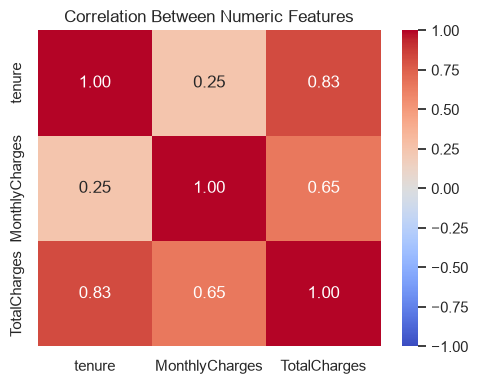

In [14]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

**Insight:** `TotalCharges` is strongly correlated with both `tenure` (r = 0.83) and
`MonthlyCharges` (r = 0.65), which is expected since it's built from those two fields. Notably,
`tenure` and `MonthlyCharges` are only weakly correlated with each other (r = 0.25), so they carry
mostly independent information. This is useful to know for Deliverable 2: `TotalCharges` would be
a "leaky" or redundant regression target if `tenure` is also used as a feature (a model could
mostly just learn tenure), so `MonthlyCharges` is the more interesting, more independent
regression target to predict from service/plan features.

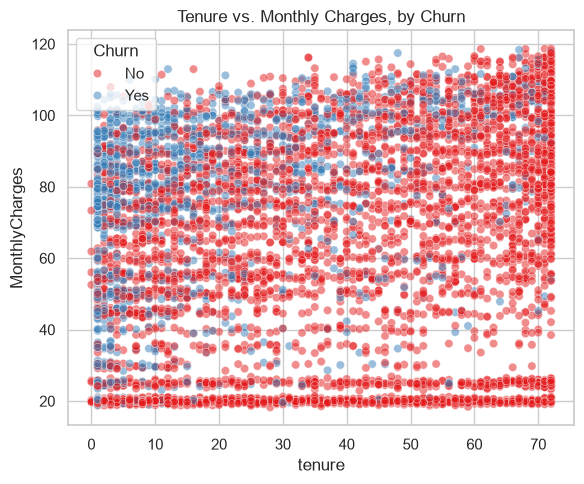

In [15]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_clean, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5, palette="Set1")
plt.title("Tenure vs. Monthly Charges, by Churn")
plt.tight_layout()
plt.show()

**Insight:** churned customers (orange) are concentrated at low tenure across the full range
of monthly charges, reinforcing that **tenure/contract length**, not price alone, is the dominant
driver of churn risk in this dataset.

## 5. Summary of Insights and Implications for Future Work

**Key insights from cleaning:**
- The only real data quality issue was `TotalCharges` being stored as text with 11 blank entries,
  all belonging to brand-new (`tenure == 0`) customers. Converted to numeric and filled with 0 for
  those rows.
- No duplicate records and no invalid numeric ranges were found.
- `customerID` was dropped as a non-predictive identifier; `SeniorCitizen` was recoded to
  `Yes`/`No` for consistency with the rest of the categorical fields.

**Key insights from EDA:**
- The target class (`Churn`) is moderately imbalanced (~26.5% Yes) - future classification work
  will need metrics beyond accuracy (F1, ROC-AUC) and possibly class balancing.
- `tenure` is bimodal (many very new and many very loyal customers); `MonthlyCharges` is
  multi-modal, likely reflecting distinct service tiers; `TotalCharges` is right-skewed and highly
  correlated with `tenure`, making it a somewhat redundant regression target compared to
  `MonthlyCharges`.
- Month-to-month contracts, fiber optic internet, and electronic check payment are all associated
  with substantially higher churn rates - strong candidate predictors for classification, strong
  candidate items for association rule mining, and useful grouping variables for clustering.
- No extreme outliers were found in the numeric fields, so no trimming/winsorizing was needed.

**How this guides the next deliverables:**
- **Deliverable 2 (Regression):** predict `MonthlyCharges` (preferred over `TotalCharges`, which
  is largely a function of `tenure`) from service/plan features; consider a log transform if
  `TotalCharges` is used instead.
- **Deliverable 3 (Classification):** predict `Churn`, using `Contract`, `InternetService`,
  `PaymentMethod`, and `tenure` as likely top predictors; use F1/ROC-AUC given class imbalance.
- **Deliverable 3 (Clustering):** segment customers on `tenure`, `MonthlyCharges`, and service
  add-ons to find natural customer segments (e.g., new/high-price/fiber vs. loyal/low-price/DSL).
- **Deliverable 3 (Association Rule Mining):** mine the categorical service/contract/payment
  columns for rules that frequently co-occur with `Churn = Yes`.